<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_project_for_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A Predictive Analysis of Real Estate Investment Decisions Using XGBoost**

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

< 전처리 순서 >

1. 각 연도 df 읽기
2. 각 연도 df에서 논문 기초통계량 17개 변수만 추출
3. 컬럼명을 분석용 공통 이름으로 변경
4. 연도 변수 추가
5. 2019~2025 데이터 병합
6. 코드형 변수 값 분포 확인
7. 논문 기준 더미 변수 생성
8. 불필요한 raw 변수 제거
9. 전체 데이터 결측치 확인
10. 전체 데이터 자료형 확인 및 숫자형 변환
11. 최종 분석용 데이터 완성

## **1. 각 연도 df 읽기**
   - 2019~2025년 csv 읽기
   - data_dict에 저장

In [47]:
base_path = '/content/drive/MyDrive/ESAA_OB_pj/논문/가구데이터'

# MDIS 자료는 보통 utf-8이 아니라 cp949 또는 euc-kr 인코딩인 경우가 많음
def read_csv_korean(file_path):
    try:
        df = pd.read_csv(file_path, encoding='cp949')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='euc-kr')

    return df

In [48]:
data_dict = {}

for year in range(2019, 2026):
    file_path = f'{base_path}/{year}.csv'
    df = read_csv_korean(file_path)
    data_dict[year] = df
    print(f'{year}년 데이터 읽기 완료 | shape: {df.shape}')

2019년 데이터 읽기 완료 | shape: (18406, 159)
2020년 데이터 읽기 완료 | shape: (18064, 159)
2021년 데이터 읽기 완료 | shape: (18187, 160)
2022년 데이터 읽기 완료 | shape: (17954, 160)
2023년 데이터 읽기 완료 | shape: (18094, 160)
2024년 데이터 읽기 완료 | shape: (18314, 162)
2025년 데이터 읽기 완료 | shape: (18664, 160)


In [49]:
# 2019~2025년 데이터 컬럼명 확인

for year in range(2019, 2026):
    file_path = f'{base_path}/{year}.csv'

    try:
        df = pd.read_csv(file_path, encoding='cp949')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='euc-kr')

    print('=' * 80)
    print(f'{year}년 데이터')
    print(f'데이터 크기: {df.shape}')
    print(f'컬럼 개수: {len(df.columns)}')
    print()
    print(df.columns.tolist())
    print()

2019년 데이터
데이터 크기: (18406, 159)
컬럼 개수: 159

['조사연도', 'MD제공용_가구고유번호', '가중값', '수도권여부', '가구주_성별코드', '가구원수', '노인가구코드', '조손가구코드', '한부모가구코드', '다문화가구코드', '보완_등록장애인유무_가구구분코드', '가구주_교육정도_학력코드', '가구주_교육정도_수학구분코드', '가구주_교육정도_통합코드', '가구주_동거여부', '가구주_산업대분류코드', '가구주_직업대분류코드', '가구주_만연령', '가구주연령_10세단위코드', '가구주_종사상지위코드', '보도용_가구주_종사상지위코드', '가구주_혼인상태코드', '입주형태코드', '입주형태통합코드', '전용면적규모코드', '주택종류통합코드', '부채보유여부', '보완_소득5분위코드', '보완_소득10분위코드', '보도용_보완_소득계층구간코드', '자산총액5분위코드', '자산총액10분위코드', '순자산5분위코드', '순자산10분위코드', '자산', '자산_금융자산', '자산_금융자산_저축금액', '자산_금융자산_저축_적립예치식저축금액', '자산_금융자산_저축_적립예치식저축_수시적립예치식저축금액', '자산_금융자산_저축_적립예치식저축_저축성보장성보험금액', '자산_금융자산_저축_적립예치식저축_주식채권펀드금액', '자산_금융자산_저축_기타저축금액', '자산_금융자산_현거주지전월세보증금', '자산_실물자산', '자산_실물자산_부동산금액', '자산_실물자산_부동산_거주주택금액', '자산_실물자산_부동산_거주주택이외부동산금액', '자산_실물자산_부동산_계약금중도금납입금액', '자산_실물자산_기타실물자산', '자산_실물자산_기타실물자산_자동차금액', '자산_실물자산_기타실물자산_기타금액', '자산_실물자산_기타실물자산_기타_자동차이외기타실물자산', '자산_실물자산_기타실물자산_기타_권리금', '부채', '부채_금융부채', '부채_금융부채_담보대출금액', '부채_금융부채_담보대출_대출용도_거주주택구입금액', '부채_금융부채_담보대출_대출용

## **2. 각 연도 df에서 논문 기초통계량 17개 변수만 추출**
   - col_map 기준으로 후보 컬럼 중 존재하는 컬럼 선택
   - 코드북이랑 대응되는 컬럼 추출

In [50]:
col_map = {
    'investment_decision': ['여유자금부동산투자여부'],
    'sma': ['수도권여부'],
    'head_gender': ['가구주_성별코드'],
    'college_or_higher_raw': ['가구주_교육정도_통합코드'],
    'own_house_raw': ['입주형태코드', '입주형태통합코드'],
    'income_decile': ['보완_소득10분위코드', '소득10분위코드(보완)(2017년~)'],
    'household_members': ['가구원수'],
    'head_age': ['가구주_만연령'],
    'financial_assets': ['자산_금융자산'],
    'real_assets': ['자산_실물자산'],
    'secured_loan': ['부채_금융부채_담보대출금액'],
    'unsecured_loan': ['부채_금융부채_신용대출금액'],
    'principal_interest_repayment': ['원리금상환금액'],
    'net_worth': ['순자산'],
    'current_income': ['보완_경상소득', '경상소득(보완)'],
    'expenditure': ['지출_소비지출비'],
    'repayment_to_income_ratio': ['원리금상환_생계부담_소득대비상환액비중']
}

In [51]:
# col_map에 들어간 후보 컬럼들이 각 연도에 존재하는지 확인

exist_check = []

for year, df in data_dict.items():
    for analysis_var, candidate_cols in col_map.items():

        matched_col = None

        for col in candidate_cols:
            if col in df.columns:
                matched_col = col
                break

        exist_check.append({
            'year': year,
            'analysis_var': analysis_var,
            'matched_column': matched_col,
            'exists': matched_col is not None
        })

exist_df = pd.DataFrame(exist_check)

exist_df

,year,analysis_var,matched_column,exists
0,2019,investment_decision,여유자금부동산투자여부,True
1,2019,sma,수도권여부,True
2,2019,head_gender,가구주_성별코드,True
3,2019,college_or_higher_raw,가구주_교육정도_통합코드,True
4,2019,own_house_raw,입주형태코드,True
...,...,...,...,...
114,2025,principal_interest_repayment,원리금상환금액,True
115,2025,net_worth,순자산,True
116,2025,current_income,경상소득(보완),True
117,2025,expenditure,지출_소비지출비,True


In [52]:
# 존재하지 않는 변수 확인

missing_df = exist_df[exist_df['exists'] == False]

missing_df

,year,analysis_var,matched_column,exists


- 존재하지 않는 변수 없음 -> 대응되는 컬럼 추출 완료
> col_map에 넣은 후보 컬럼들이 2019~2025년 모든 데이터에서 하나씩 정상적으로 매칭됐다는 뜻

## **3. 컬럼명을 분석용 공통 이름으로 변경**
   - 예: 여유자금부동산투자여부 → investment_decision
   - 예: 보완_경상소득 / 경상소득(보완) → current_income

## **4. 연도 변수 추가**
   - year = 2019, 2020, ..., 2025

## **5. 2019~2025 데이터 병합**
   - df_all 생성

In [53]:
# 여러 후보 컬럼 중 실제 존재하는 컬럼을 찾는 함수

def get_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

In [54]:
# 각 연도 df에서 17개 변수만 추출하고 공통 컬럼명으로 변경

processed_dfs = []

for year, df in data_dict.items():
    temp = pd.DataFrame()

    for analysis_var, candidate_cols in col_map.items():
        matched_col = get_existing_col(df, candidate_cols)
        temp[analysis_var] = df[matched_col]

    temp['year'] = year

    processed_dfs.append(temp)

df_all = pd.concat(processed_dfs, ignore_index=True)

print(df_all.shape)
df_all.head()

(127683, 18)


,investment_decision,sma,head_gender,college_or_higher_raw,own_house_raw,income_decile,household_members,head_age,financial_assets,real_assets,secured_loan,unsecured_loan,principal_interest_repayment,net_worth,current_income,expenditure,repayment_to_income_ratio,year
0,1,G1,1,G4,2,D04,6,56,12460,32000,4000,7000,1285,25620,3360,4044,NaN,2019
1,2,G1,2,G2,2,D05,2,64,38310,48175,0,0,0,79485,4090,3125,NaN,2019
2,2,G1,1,G3,1,D01,2,84,200,20150,0,0,0,20350,774,1350,NaN,2019
3,2,G1,1,G3,1,D08,4,57,2268,44230,10000,0,1430,36198,7411,3070,NaN,2019
4,1,G1,1,G4,1,D09,5,56,25674,132500,23000,900,1085,134274,10219,4940,NaN,2019


- 3~5 단계 한 번에 시행

## **6. 코드형 변수 값 분포 확인**
   - investment_decision, sma, head_gender, college_or_higher_raw, own_house_raw, income_decile 확인

In [55]:
# 코드형 변수 값 분포 확인

code_cols = [
    'investment_decision',
    'sma',
    'head_gender',
    'college_or_higher_raw',
    'own_house_raw',
    'income_decile'
]

for col in code_cols:
    print('=' * 80)
    print(col)
    print(df_all[col].value_counts(dropna=False).sort_index())

investment_decision
investment_decision
1    61246
2    66437
Name: count, dtype: int64
sma
sma
G1    41431
G2    86252
Name: count, dtype: int64
head_gender
head_gender
1    92407
2    35276
Name: count, dtype: int64
college_or_higher_raw
college_or_higher_raw
G1    24374
G2    13876
G3    41312
G4    48121
Name: count, dtype: int64
own_house_raw
own_house_raw
1    78890
2    14823
3    23489
4     1802
5     8679
Name: count, dtype: int64
income_decile
income_decile
D01    16620
D02    15516
D03    13898
D04    12974
D05    12428
D06    11914
D07    11403
D08    11069
D09    10902
D10    10959
Name: count, dtype: int64


## **7. 논문 기준 더미 변수 생성**
   - 투자=1
   - 수도권=1
   - 남자=1
   - 대학졸업 이상=1
   - 자가=1
   - 소득10분위는 숫자형 1~10으로 변환

> 코드북이랑 비교한 결과

investment_decision: 1 = 투자, 2 = 비투자

sma: G1 = 수도권, G2 = 비수도권

head_gender: 1 = 남자, 2 = 여자

college_or_higher_raw: G4 = 대학졸업 이상

own_house_raw: 1 = 자가

income_decile: D01 ~ D10 = 소득 1 ~ 10분위

In [56]:
df_all['investment_decision'] = (df_all['investment_decision'] == 1).astype(int)

df_all['sma'] = (df_all['sma'] == 'G1').astype(int)

df_all['head_gender'] = (df_all['head_gender'] == 1).astype(int)

df_all['college_or_higher'] = (df_all['college_or_higher_raw'] == 'G4').astype(int)

df_all['own_house'] = (df_all['own_house_raw'] == 1).astype(int)

df_all['income_decile'] = df_all['income_decile'].str.replace('D', '', regex=False).astype(int)

In [57]:
# 더미 변수 변환 결과 확인

check_cols = [
    'investment_decision',
    'sma',
    'head_gender',
    'college_or_higher',
    'own_house',
    'income_decile'
]

for col in check_cols:
    print('=' * 80)
    print(col)
    print(df_all[col].value_counts(dropna=False).sort_index())

investment_decision
investment_decision
0    66437
1    61246
Name: count, dtype: int64
sma
sma
0    86252
1    41431
Name: count, dtype: int64
head_gender
head_gender
0    35276
1    92407
Name: count, dtype: int64
college_or_higher
college_or_higher
0    79562
1    48121
Name: count, dtype: int64
own_house
own_house
0    48793
1    78890
Name: count, dtype: int64
income_decile
income_decile
1     16620
2     15516
3     13898
4     12974
5     12428
6     11914
7     11403
8     11069
9     10902
10    10959
Name: count, dtype: int64


- 변환 완료

## **8. 불필요한 raw 변수 제거**
   - college_or_higher_raw
   - own_house_raw 등

In [58]:
df_all = df_all.drop(columns=[
    'college_or_higher_raw',
    'own_house_raw'
])

- investment_decision, sma, head_gender, income_decile은 기존 컬럼을 그대로 변환했기 때문에 제거하면 안됨

## **9. 전체 데이터 결측치 확인**
   - 변수별 결측 개수 확인
   - 결측 처리 방식 결정

In [59]:
missing_summary = df_all.isna().sum().sort_values(ascending=False)
missing_summary

,0
repayment_to_income_ratio,105707
investment_decision,0
sma,0
head_gender,0
household_members,0
income_decile,0
financial_assets,0
real_assets,0
secured_loan,0
head_age,0


## **10. 전체 데이터 자료형 확인 및 숫자형 변환**
   - 금액 변수, 소득 변수, 지출 변수 numeric 처리



In [60]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127683 entries, 0 to 127682
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   investment_decision           127683 non-null  int64  
 1   sma                           127683 non-null  int64  
 2   head_gender                   127683 non-null  int64  
 3   income_decile                 127683 non-null  int64  
 4   household_members             127683 non-null  int64  
 5   head_age                      127683 non-null  int64  
 6   financial_assets              127683 non-null  int64  
 7   real_assets                   127683 non-null  int64  
 8   secured_loan                  127683 non-null  int64  
 9   unsecured_loan                127683 non-null  int64  
 10  principal_interest_repayment  127683 non-null  int64  
 11  net_worth                     127683 non-null  int64  
 12  current_income                127683 non-nul

- repayment_to_income_ratio
  - 정수형 컬럼에 NaN이 섞이면 보통 float64로 처리

repayment_to_income_ratio: 원리금 상환액이 있는 가구에만 의미 있는 변수

-> 결측치 대부분은 부채가 없어서 원리금 상환이 없고 비율 계산 불가이므로 결측이 "상환액 없음"이라는 정보를 내포

-> 결측 자체를 피처로 이용

- repayment_to_income_ratio : 결측 -> 0으로 대체
- has_repayment : 원리금 상황 가구 여부 더미


In [61]:
# 결측 여부 더미 변수 생성 (1 = 원리금 상환 있음, 0 = 없음/결측)
df_all['has_repayment'] = df_all['repayment_to_income_ratio'].notna().astype(int)

# 결측치 0으로 대체 (float64 유지)
df_all['repayment_to_income_ratio'] = df_all['repayment_to_income_ratio'].fillna(0)

# 확인
print(df_all[['repayment_to_income_ratio', 'has_repayment']].info())
print()
print(df_all['has_repayment'].value_counts())
print()
print(df_all['repayment_to_income_ratio'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127683 entries, 0 to 127682
Data columns (total 2 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   repayment_to_income_ratio  127683 non-null  float64
 1   has_repayment              127683 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 1.9 MB
None

has_repayment
0    105707
1     21976
Name: count, dtype: int64

count    127683.000000
mean          3.584675
std           8.959213
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          80.000000
Name: repayment_to_income_ratio, dtype: float64


In [62]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127683 entries, 0 to 127682
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   investment_decision           127683 non-null  int64  
 1   sma                           127683 non-null  int64  
 2   head_gender                   127683 non-null  int64  
 3   income_decile                 127683 non-null  int64  
 4   household_members             127683 non-null  int64  
 5   head_age                      127683 non-null  int64  
 6   financial_assets              127683 non-null  int64  
 7   real_assets                   127683 non-null  int64  
 8   secured_loan                  127683 non-null  int64  
 9   unsecured_loan                127683 non-null  int64  
 10  principal_interest_repayment  127683 non-null  int64  
 11  net_worth                     127683 non-null  int64  
 12  current_income                127683 non-nul

## **10-2 추가 전처리 확인**

클래스 불균형 확인

XGBoost는 이상치에 덜 민감하므로 굳이 이상치를 없애지 않아도 될 것 같음
- Winsorizing 방식을 이용해 이상치 1~5%의 변수를 전처리하는 방식을 이용해 봤지만 상한과 하한이 잘못 잡히는 문제가 있어서 굳이 진행하지 않아도 될 듯함

다중공선성 확인





In [63]:
# 클래스 불균형 확인
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

investment_decision
0    66437
1    61246
Name: count, dtype: int64

investment_decision
0    52.032769
1    47.967231
Name: proportion, dtype: float64


In [64]:
# 연속형 금액 변수 이상치 현황 확인
continuous_cols = [
    'financial_assets', 'real_assets', 'net_worth',
    'current_income', 'expenditure',
    'secured_loan', 'unsecured_loan',
    'principal_interest_repayment', 'repayment_to_income_ratio',
    'household_members', 'head_age'
]

for col in continuous_cols:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df_all[col] < Q1 - 1.5*IQR) | (df_all[col] > Q3 + 1.5*IQR)).sum()
    outlier_pct = outlier_count / len(df_all) * 100
    print(f"{col:35s} | 이상치: {outlier_count:6d}개 ({outlier_pct:.2f}%)")

financial_assets                    | 이상치:  11067개 (8.67%)
real_assets                         | 이상치:   9449개 (7.40%)
net_worth                           | 이상치:   9831개 (7.70%)
current_income                      | 이상치:   5718개 (4.48%)
expenditure                         | 이상치:   4203개 (3.29%)
secured_loan                        | 이상치:  20400개 (15.98%)
unsecured_loan                      | 이상치:  24633개 (19.29%)
principal_interest_repayment        | 이상치:  13959개 (10.93%)
repayment_to_income_ratio           | 이상치:  21976개 (17.21%)
household_members                   | 이상치:    171개 (0.13%)
head_age                            | 이상치:      2개 (0.00%)


/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight

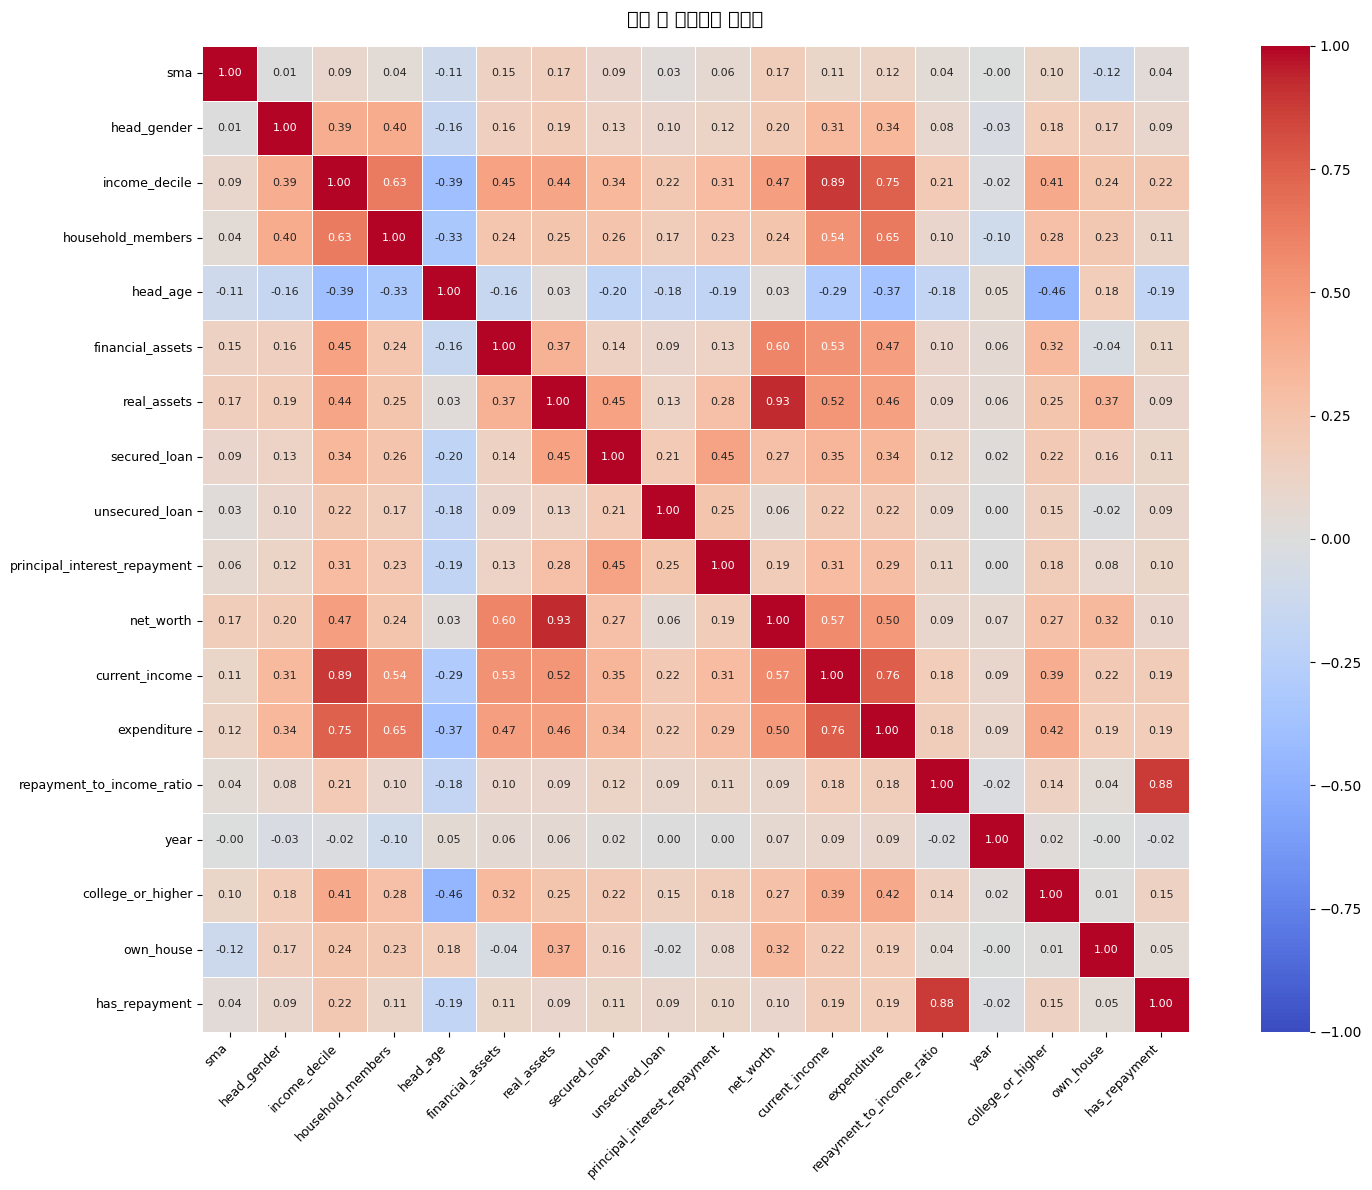


|상관계수| >= 0.7 변수 쌍
income_decile                       & current_income                      | r = 0.887
income_decile                       & expenditure                         | r = 0.749
real_assets                         & net_worth                           | r = 0.928
current_income                      & expenditure                         | r = 0.755
repayment_to_income_ratio           & has_repayment                       | r = 0.881


In [65]:
# 다중공선성 확인

import matplotlib.pyplot as plt
import seaborn as sns

# 최종 X 변수 기준으로 상관행렬 계산
X_winsor = df_all_winsor.drop(columns=['investment_decision'])

corr_matrix = X_winsor.corr()

# 히트맵 시각화
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('변수 간 상관관계 히트맵', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# 높은 상관관계 쌍 출력 (|r| >= 0.7)
print("\n|상관계수| >= 0.7 변수 쌍")
print('=' * 60)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.7:
            print(f"{corr_matrix.columns[i]:35s} & {corr_matrix.columns[j]:35s} | r = {r:.3f}")

**높은 상관관계 쌍 분석**

1. real_assets & net_worth (r = 0.928) ← 가장 심각
- net_worth = 자산 - 부채 이므로 real_assets가 클수록 net_worth도 커지는 구조적 관계
- net_worth 제거 권장 → real_assets, financial_assets, 대출 변수들로 이미 순자산 정보가 분해되어 있음

2. repayment_to_income_ratio & has_repayment (r = 0.881)
- has_repayment가 1일 때만 repayment_to_income_ratio가 0이 아닌 구조적 관계
- has_repayment 제거 권장 → repayment_to_income_ratio 자체가 0/비0으로 이미 상환 여부를 내포

3. income_decile & current_income (r = 0.887)
- 소득분위는 소득액으로 결정되므로 당연한 관계
- income_decile 제거 권장 → current_income이 연속형으로 더 많은 정보 보유

4. income_decile & expenditure (r = 0.749)
- 위와 동일 원인 (income_decile 제거로 자동 해소)

5. current_income & expenditure (r = 0.755)
- 소득이 높을수록 지출도 높은 자연스러운 관계
- 두 변수 모두 독립적 의미가 있으므로 유지 권장

In [67]:
df_all_winsor = df_all_winsor.drop(columns=[
    'net_worth',        # real_assets와 중복
    'has_repayment',    # repayment_to_income_ratio에 내포
    'income_decile'     # current_income과 중복
])

print(f"최종 컬럼 수: {df_all_winsor.shape[1]}")
print(df_all_winsor.columns.tolist())

최종 컬럼 수: 16
['investment_decision', 'sma', 'head_gender', 'household_members', 'head_age', 'financial_assets', 'real_assets', 'secured_loan', 'unsecured_loan', 'principal_interest_repayment', 'current_income', 'expenditure', 'repayment_to_income_ratio', 'year', 'college_or_higher', 'own_house']


In [68]:
df_all=df_all_winsor

## **11. 최종 분석용 데이터 완성**
   - y = investment_decision
   - X = 나머지 설명변수

In [69]:
X = df_all.drop(columns=['investment_decision'])
y = df_all['investment_decision']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny 분포:\n{y.value_counts()}")
print(f"\nX 컬럼 목록:\n{X.columns.tolist()}")

X shape: (127683, 15)
y shape: (127683,)

y 분포:
investment_decision
0    66437
1    61246
Name: count, dtype: int64

X 컬럼 목록:
['sma', 'head_gender', 'household_members', 'head_age', 'financial_assets', 'real_assets', 'secured_loan', 'unsecured_loan', 'principal_interest_repayment', 'current_income', 'expenditure', 'repayment_to_income_ratio', 'year', 'college_or_higher', 'own_house']
